In [22]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [4]:
df = pd.read_csv("coffee-planning.csv")
df

,idx,model,prompt,len_plan,temperature,action1,action2,action3,action4,action5,action6,action7,action8,action9,action10
0,0,phi4:14b,p-20250211-22-00.txt,6,0.0,navigate_to(kitchen),look_for_item('coffee_machine'),if coffee_machine is found: ask_human_for_help...,else: say('I couldn't find a coffee machine. W...,navigate_to(user123),handover(coffee),NaN,NaN,NaN,NaN
1,1,phi4:14b,p-20250211-22-00.txt,3,0.1,navigate_to(kitchen),ask_human_for_help('Can you please make a coff...,"carry_object('coffee', 'reception')",NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,phi4:14b,p-20250211-22-00.txt,4,0.1,navigate_to(kitchen),look_for_item('coffee_machine'),if coffee_machine is found: ask_human_for_help...,else: say('I couldn't find the coffee machine....,NaN,NaN,NaN,NaN,NaN,NaN
3,3,phi4:14b,p-20250211-22-00.txt,3,0.1,navigate_to(kitchen),ask_human_for_help('Can you please make a coff...,"carry_object('coffee', 'reception')",NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,phi4:14b,p-20250211-22-00.txt,4,0.1,navigate_to(kitchen),look_for_item('hasType coffee_machine'),ask_human_for_help('Can you please make a coff...,"carry_object('coffee', 'reception')",NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
446,446,phi4:14b,p-20250211-22-00.txt,4,0.5,navigate_to(kitchen),look_for_item('hasType Coffee'),"if found: carry_object(coffee, reception)",else: ask_human_for_help('Could you please get...,NaN,NaN,NaN,NaN,NaN,NaN
447,447,phi4:14b,p-20250211-22-00.txt,5,0.5,navigate_to(kitchen),ask_human_for_help('Can you please make a coff...,"carry_object('coffee', 'reception')",navigate_to(user123),handover('coffee'),NaN,NaN,NaN,NaN,NaN
448,448,phi4:14b,p-20250211-22-00.txt,2,0.5,navigate_to(kitchen),ask_human_for_help('Could you please make a cu...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
449,449,phi4:14b,p-20250211-22-00.txt,2,0.5,navigate_to(kitchen),ask_human_for_help('Can you help me make a cof...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<Axes: >

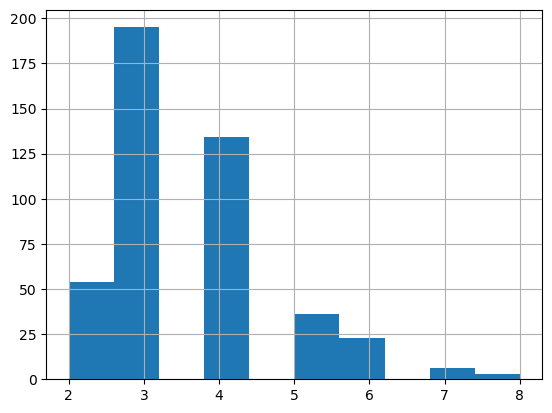

In [24]:
df.len_plan.hist()

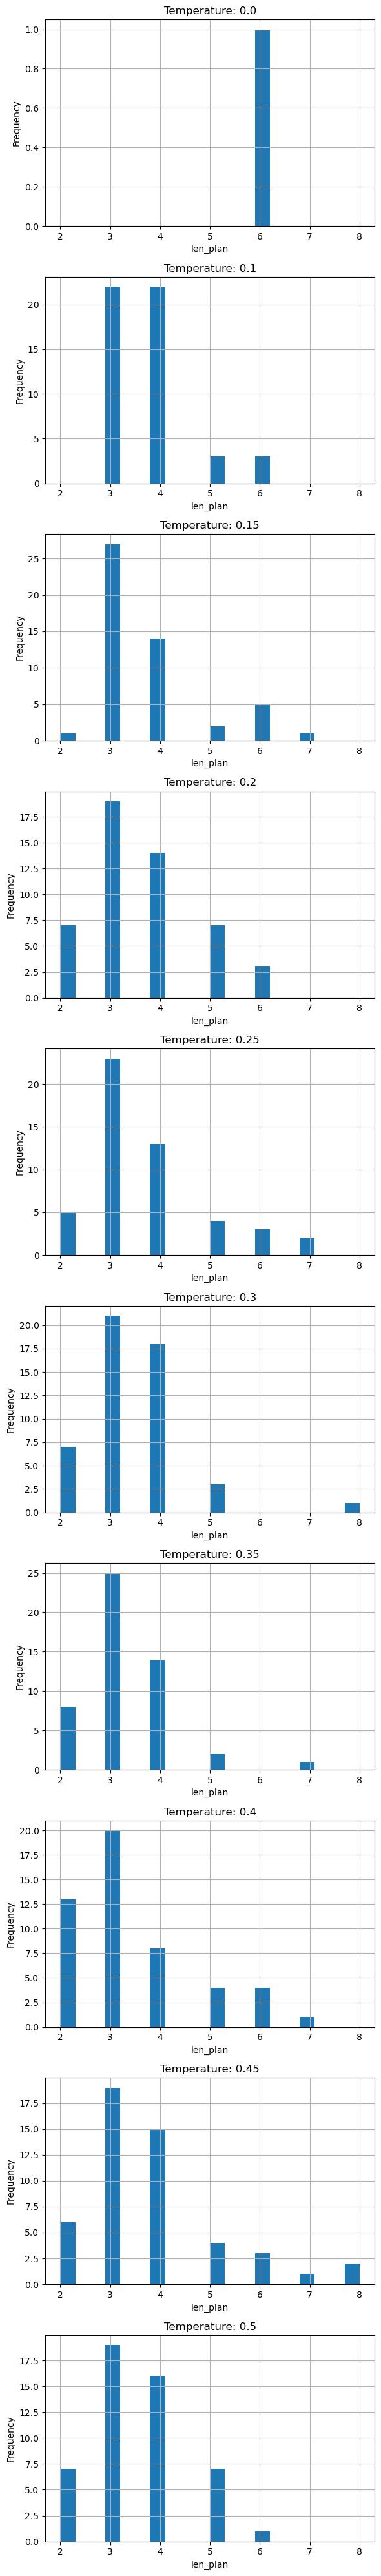

In [23]:
# Define the bins based on the overall data range
bin_edges = np.histogram_bin_edges(df.len_plan, bins=20)

# Get unique temperature values
unique_temps = df.temperature.unique()

# Create subplots with an appropriate number of rows and columns
fig, axes = plt.subplots(nrows=len(unique_temps), figsize=(6, 4 * len(unique_temps)))

# Ensure axes is iterable even if there's only one subplot
if len(unique_temps) == 1:
    axes = [axes]

# Loop through each temperature group and plot the histogram
for ax, temp in zip(axes, unique_temps):
    df[df.temperature == temp].len_plan.hist(ax=ax, bins=bin_edges)
    ax.set_title(f'Temperature: {temp}')
    ax.set_xlabel('len_plan')
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()